# Alzheimer's Disease Brain MRI — Multi-Class Tissue Segmentation
## VGG19 + UNet++ | 4-Class (Background / CSF / Grey Matter / White Matter) | IBSR Dataset

**Dataset:** Internet Brain Segmentation Repository (IBSR) — 18 subjects, expert-annotated tri-class tissue segmentation (`segTRI`).

**Architecture:** VGG19 encoder (ImageNet pre-trained) with UNet++ decoder featuring dense nested skip connections for richer multi-scale feature reuse.

**Why multi-class directly (no binary step):** The binary-then-multiclass pipeline was already validated on OASIS-1. Since IBSR's `segTRI` masks use the same 4-label convention (0=background, 1=CSF, 2=GM, 3=WM), we go directly to multi-class here.

**Note:** EarlyStopping disabled — model trains for the full configured epochs as instructed.

**Note on CSF class:** IBSR's CSF label is far sparser (~0.17% of voxels) than OASIS-1's (~7.5%) — expect CSF IoU to be a harder, noisier metric here purely due to extreme class imbalance.


## 1. Import Libraries

In [43]:
import os
import re
import cv2
import random
import shutil
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, UpSampling2D, concatenate, BatchNormalization, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG19
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration & Extraction

In [44]:
# ─── Paths ────────────────────────────────────────────────────────────────────
IBSR_TGZ_PATH = '/kaggle/input/datasets/maheswarimudadla/ibsr-dataset/IBSR_V2.0_nifti_stripped.tgz'
EXTRACT_DIR   = '/kaggle/working/ibsr_extracted'
IBSR_ROOT     = os.path.join(EXTRACT_DIR, 'IBSR_nifti_stripped')

PROCESSED_DIR   = 'ibsr_processed'
IMAGE_FOLDER    = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER     = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR   = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR  = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR    = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR   = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.15
NUM_CLASSES = 4   # 0=background, 1=CSF, 2=Grey Matter, 3=White Matter
CLASS_NAMES = ['Background', 'CSF', 'Grey Matter', 'White Matter']

print('Config set ✓')


Config set ✓


In [45]:
if not os.path.exists(IBSR_ROOT):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    print('Extracting IBSR archive...')
    with tarfile.open(IBSR_TGZ_PATH, 'r:gz') as tar:
        tar.extractall(path=EXTRACT_DIR)
    print('Extraction done ✓')
else:
    print('Already extracted ✓')

subject_folders = sorted([
    d for d in os.listdir(IBSR_ROOT)
    if os.path.isdir(os.path.join(IBSR_ROOT, d)) and d.startswith('IBSR_')
])
print(f'Found {len(subject_folders)} subjects: {subject_folders}')


Already extracted ✓
Found 18 subjects: ['IBSR_01', 'IBSR_02', 'IBSR_03', 'IBSR_04', 'IBSR_05', 'IBSR_06', 'IBSR_07', 'IBSR_08', 'IBSR_09', 'IBSR_10', 'IBSR_11', 'IBSR_12', 'IBSR_13', 'IBSR_14', 'IBSR_15', 'IBSR_16', 'IBSR_17', 'IBSR_18']


## 3. Extract 2D Slices — Keep All 4 Tissue Labels

In [46]:
def make_dir(path):
    os.makedirs(path, exist_ok=True)

for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    make_dir(d)

print('Directories ready ✓')


Directories ready ✓


In [47]:
def normalize_slice(arr):
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)

def extract_slices_ibsr(subject_dir, subject_name, img_out, mask_out, step=1):
    brain_path = os.path.join(subject_dir, f'{subject_name}_ana_strip.nii.gz')
    seg_path   = os.path.join(subject_dir, f'{subject_name}_segTRI_ana.nii')
    if not os.path.exists(brain_path) or not os.path.exists(seg_path):
        print(f'  Skipping {subject_name} — missing file(s)')
        return 0
    brain_vol = np.squeeze(nib.load(brain_path).get_fdata())
    seg_vol   = np.squeeze(nib.load(seg_path).get_fdata())
    saved = 0
    for i in range(0, brain_vol.shape[1], step):
        b_sl   = brain_vol[:, i, :]
        seg_sl = seg_vol[:, i, :]
        if b_sl.max() == 0:
            continue
        img_arr  = normalize_slice(b_sl)
        mask_arr = np.round(seg_sl).astype(np.uint8)
        mask_arr = np.clip(mask_arr, 0, NUM_CLASSES - 1)
        fname = f'{subject_name}_sl{i:03d}.png'
        cv2.imwrite(os.path.join(img_out,  fname), img_arr)
        cv2.imwrite(os.path.join(mask_out, fname), mask_arr)
        saved += 1
    return saved

for folder in [IMAGE_FOLDER, MASK_FOLDER]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

total_slices = 0
for subj_name in tqdm(subject_folders, desc='Extracting slices'):
    subj_dir = os.path.join(IBSR_ROOT, subj_name)
    total_slices += extract_slices_ibsr(subj_dir, subj_name, IMAGE_FOLDER, MASK_FOLDER, step=1)

print(f'Total slices extracted : {total_slices}')
print(f'Images saved           : {len(os.listdir(IMAGE_FOLDER))}')
print(f'Masks  saved           : {len(os.listdir(MASK_FOLDER))}')


Extracting slices:   0%|          | 0/18 [00:00<?, ?it/s]

  Skipping IBSR_02 — missing file(s)
  Skipping IBSR_03 — missing file(s)
  Skipping IBSR_04 — missing file(s)
  Skipping IBSR_05 — missing file(s)
  Skipping IBSR_07 — missing file(s)
  Skipping IBSR_08 — missing file(s)
  Skipping IBSR_09 — missing file(s)
  Skipping IBSR_10 — missing file(s)
  Skipping IBSR_11 — missing file(s)
  Skipping IBSR_12 — missing file(s)
  Skipping IBSR_13 — missing file(s)
  Skipping IBSR_14 — missing file(s)
  Skipping IBSR_15 — missing file(s)
  Skipping IBSR_16 — missing file(s)
  Skipping IBSR_17 — missing file(s)
  Skipping IBSR_18 — missing file(s)
Total slices extracted : 236
Images saved           : 236
Masks  saved           : 236


## 4. Verify Label Distribution & Visualize

In [48]:
sample_mask_files = random.sample(os.listdir(MASK_FOLDER), min(20, len(os.listdir(MASK_FOLDER))))
all_vals = set()
for f in sample_mask_files:
    m = cv2.imread(os.path.join(MASK_FOLDER, f), cv2.IMREAD_GRAYSCALE)
    all_vals.update(np.unique(m).tolist())
print('Unique label values found across sample masks:', sorted(all_vals))
print('Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)')


Unique label values found across sample masks: [0, 1, 2, 3]
Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)


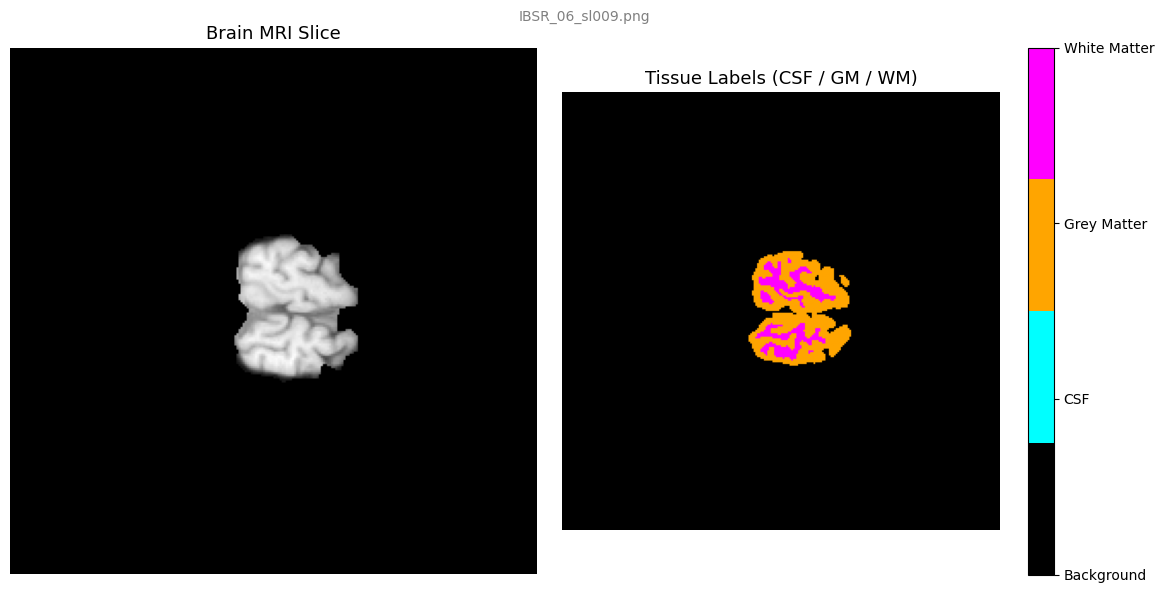

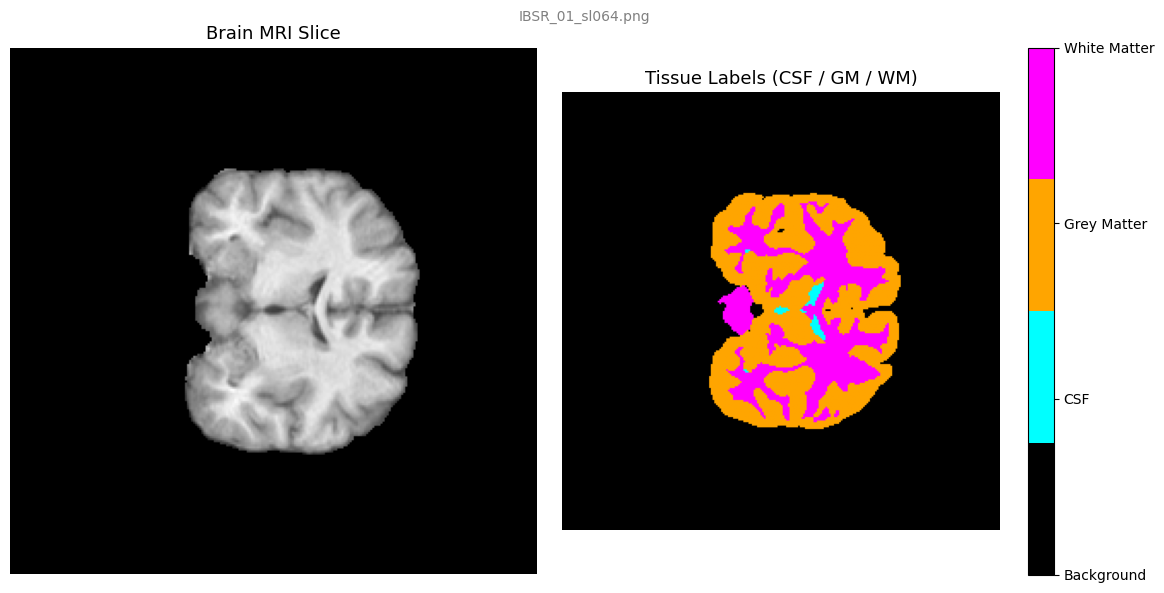

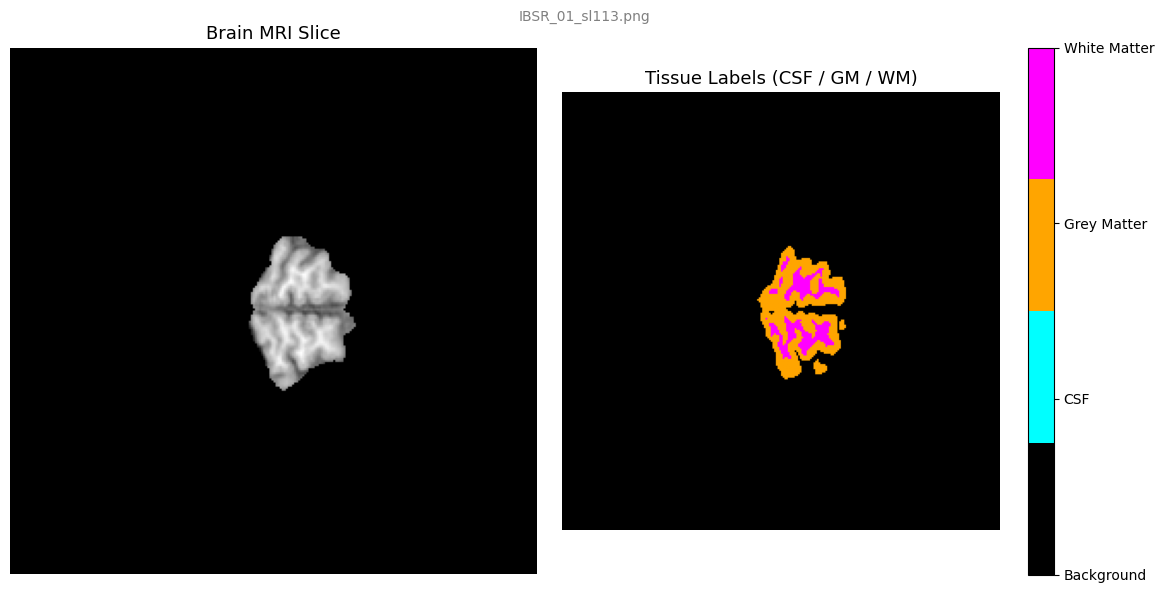

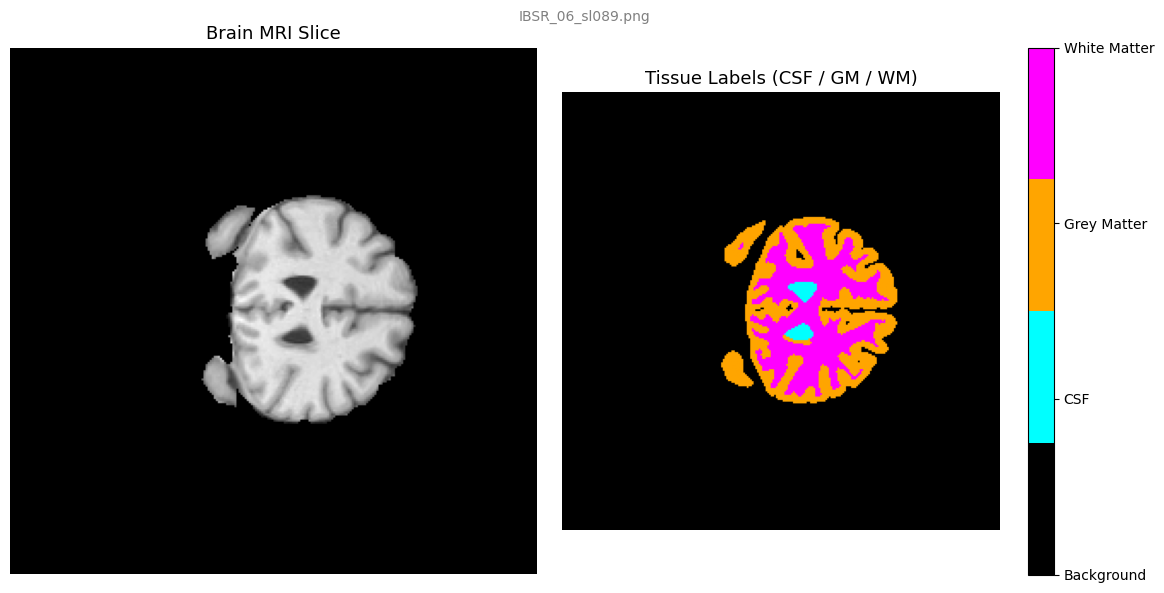

In [49]:
CLASS_COLORS = ['black', 'cyan', 'orange', 'magenta']
cmap_classes = mcolors.ListedColormap(CLASS_COLORS)

def visualize_sample_multiclass(image_name, img_dir=IMAGE_FOLDER, mask_dir=MASK_FOLDER):
    img  = cv2.imread(os.path.join(img_dir,  image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(mask_dir, image_name), cv2.IMREAD_GRAYSCALE)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img, cmap='gray'); axes[0].set_title('Brain MRI Slice', fontsize=13)
    im = axes[1].imshow(mask, cmap=cmap_classes, vmin=0, vmax=NUM_CLASSES - 1)
    axes[1].set_title('Tissue Labels (CSF / GM / WM)', fontsize=13)
    cbar = plt.colorbar(im, ax=axes[1], ticks=range(NUM_CLASSES))
    cbar.ax.set_yticklabels(CLASS_NAMES)
    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout(); plt.show()

all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample_multiclass(random.choice(all_images))


## 5. Train / Test Split

In [50]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])
assert images == masks, 'Image-mask mismatch!'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')


Train: 200  |  Test: 36


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

Files copied ✓


## 6. tf.data Pipeline — one-hot encoded masks

In [51]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = tf.cast(img, tf.float32) / 255.0
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.int32)
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.one_hot(mask, depth=NUM_CLASSES)
    mask = tf.cast(mask, tf.float32)
    return img, mask

def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask

def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])
    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)
print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes →  images:', imgs.shape, ' masks:', masks.shape)


Datasets ready ✓
Batch shapes →  images: (16, 224, 224, 3)  masks: (16, 224, 224, 4)


## 7. Model — VGG19 Encoder + UNet++ Decoder, 4-class softmax output

**UNet++ key difference vs UNet:** Dense nested skip connections. Each decoder node `X[i][j]` receives upsampled output from `X[i+1][j-1]` **plus all** prior decoder nodes at the same encoder level (`X[i][0..j-1]`). This closes the semantic gap between encoder and decoder progressively, producing richer multi-scale feature aggregation.

**VGG19 vs VGG16 layer names:** blocks 3–5 use `_conv4` (4 conv layers) instead of `_conv3`.


In [52]:
def conv_block(x, filters, name_prefix):
    """Double conv + BN + ReLU."""
    x = Conv2D(filters, (3, 3), padding='same', name=f'{name_prefix}_c1')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = Activation('relu', name=f'{name_prefix}_act1')(x)
    x = Conv2D(filters, (3, 3), padding='same', name=f'{name_prefix}_c2')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
    x = Activation('relu', name=f'{name_prefix}_act2')(x)
    return x

def unetpp_node(x_up, skip_list, filters, name_prefix):
    """
    UNet++ dense node.
    x_up      : tensor from the deeper decoder level (to be upsampled).
    skip_list : list of feature maps at this resolution (encoder skip +
                all prior decoder nodes at the same level).
    """
    x = UpSampling2D((2, 2), name=f'{name_prefix}_up')(x_up)
    x = concatenate([x] + skip_list, name=f'{name_prefix}_cat')
    x = Dropout(0.2, name=f'{name_prefix}_drop')(x)
    x = conv_block(x, filters, name_prefix)
    return x

def build_vgg19_unetpp_multiclass(input_shape=(224, 224, 3), num_classes=4, freeze_encoder=True):
    """
    VGG19 encoder + UNet++ decoder for 4-class brain tissue segmentation.

    VGG19 encoder skip connections:
      s1 = block1_conv2  224x224  64 ch
      s2 = block2_conv2  112x112  128 ch
      s3 = block3_conv4   56x56   256 ch  (VGG19 has 4 convs per block in 3-5)
      s4 = block4_conv4   28x28   512 ch
      b  = block5_conv4   14x14   512 ch  (bottleneck)
    """
    inputs = Input(shape=input_shape, name='input')
    base   = VGG19(include_top=False, weights='imagenet', input_tensor=inputs)
    if freeze_encoder:
        for layer in base.layers:
            layer.trainable = False
    # Encoder skips
    s1 = base.get_layer('block1_conv2').output  # 224x224, 64
    s2 = base.get_layer('block2_conv2').output  # 112x112, 128
    s3 = base.get_layer('block3_conv4').output  #  56x56,  256
    s4 = base.get_layer('block4_conv4').output  #  28x28,  512
    b  = base.get_layer('block5_conv4').output  #  14x14,  512
    f = [64, 128, 256, 512]  # filters per encoder level
    # Level 3 (28x28)
    x31 = unetpp_node(b,   [s4],            f[3], 'x31')
    # Level 2 (56x56)
    x21 = unetpp_node(s4,  [s3],            f[2], 'x21')
    x22 = unetpp_node(x31, [s3, x21],       f[2], 'x22')
    # Level 1 (112x112)
    x11 = unetpp_node(s3,  [s2],               f[1], 'x11')
    x12 = unetpp_node(x21, [s2, x11],          f[1], 'x12')
    x13 = unetpp_node(x22, [s2, x11, x12],     f[1], 'x13')
    # Level 0 (224x224)
    x01 = unetpp_node(s2,  [s1],                    f[0], 'x01')
    x02 = unetpp_node(x11, [s1, x01],               f[0], 'x02')
    x03 = unetpp_node(x12, [s1, x01, x02],          f[0], 'x03')
    x04 = unetpp_node(x13, [s1, x01, x02, x03],     f[0], 'x04')
    output = Conv2D(num_classes, (1, 1), activation='softmax', name='output')(x04)
    model = Model(inputs=inputs, outputs=output, name='VGG19_UNetPP_MultiClass')
    return model

model = build_vgg19_unetpp_multiclass(
    input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES, freeze_encoder=True
)
print('Model built ✓')
print(f'Total parameters      : {model.count_params():,}')
print(f'Trainable parameters  : {sum([K.count_params(w) for w in model.trainable_weights]):,}')


Model built ✓
Total parameters      : 35,450,436
Trainable parameters  : 15,419,396


## 8. Custom Metrics & Loss — categorical versions

In [53]:
def dice_coefficient_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    union = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0)
    return K.mean((2.0 * intersection + smooth) / (union + smooth))

def dice_loss_multiclass(y_true, y_pred):
    return 1.0 - dice_coefficient_multiclass(y_true, y_pred)

def iou_score_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    total = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0) - intersection
    return K.mean((intersection + smooth) / (total + smooth))

def csf_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 1]; p = y_pred[..., 1]
    i = K.sum(t * p); u = K.sum(t) + K.sum(p) - i
    return (i + smooth) / (u + smooth)

def gm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 2]; p = y_pred[..., 2]
    i = K.sum(t * p); u = K.sum(t) + K.sum(p) - i
    return (i + smooth) / (u + smooth)

def wm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 3]; p = y_pred[..., 3]
    i = K.sum(t * p); u = K.sum(t) + K.sum(p) - i
    return (i + smooth) / (u + smooth)

def pixel_accuracy_multiclass(y_true, y_pred):
    return K.mean(K.cast(K.equal(K.argmax(y_true, axis=-1), K.argmax(y_pred, axis=-1)), K.floatx()))

def combined_loss_multiclass(y_true, y_pred):
    return dice_loss_multiclass(y_true, y_pred) + tf.keras.losses.categorical_crossentropy(y_true, y_pred)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss_multiclass,
    metrics=[dice_coefficient_multiclass, iou_score_multiclass, pixel_accuracy_multiclass,
             csf_iou, gm_iou, wm_iou]
)
print('Model compiled ✓')


Model compiled ✓


## 9. Model Summary

In [54]:
model.summary()

try:
    tf.keras.utils.plot_model(
        model, to_file='vgg19_unetpp_multiclass_ibsr_architecture.png',
        show_shapes=True, show_layer_names=True, rankdir='TB', dpi=64
    )
    print('Architecture diagram saved ✓')
except Exception as e:
    print('Architecture plot skipped:', str(e)[:150])


Model: "VGG19_UNetPP_MultiClass"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv4        │ (None, 56, 56,    │    590,080 │ block3_conv3[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv4[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv4        │ (None, 28, 28,    │  2,359,808 │ block4_conv3[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv4[0][

 Total params: 35,450,436 (135.23 MB)

 Trainable params: 15,419,396 (58.82 MB)

 Non-trainable params: 20,031,040 (76.41 MB)

Architecture diagram saved ✓


## 10. Callbacks (EarlyStopping disabled)

In [55]:
def decode_mask(onehot_mask):
    return tf.argmax(onehot_mask, axis=-1)

def colorize_mask(label_map):
    colors = np.array([[0,0,0],[0,255,255],[255,165,0],[255,0,255]], dtype=np.uint8)
    return colors[np.array(label_map).astype(int)]

def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            gt_labels   = decode_mask(masks[i]).numpy()
            pred_labels = decode_mask(preds[i]).numpy()
            fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
            axes[0].imshow(imgs[i].numpy());            axes[0].set_title('Input MRI')
            axes[1].imshow(colorize_mask(gt_labels));   axes[1].set_title('Ground Truth')
            axes[2].imshow(colorize_mask(pred_labels)); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout(); plt.show()

class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')

logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_vgg19unetpp_multiclass_ibsr.keras', verbose=1,
                               save_best_only=True, monitor='val_iou_score_multiclass', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
]
print('Callbacks ready ✓ (no EarlyStopping — will run all', EPOCHS, 'epochs)')


Callbacks ready ✓ (no EarlyStopping — will run all 100 epochs)


## 11. Initial Predictions (before training)

Predictions before training:


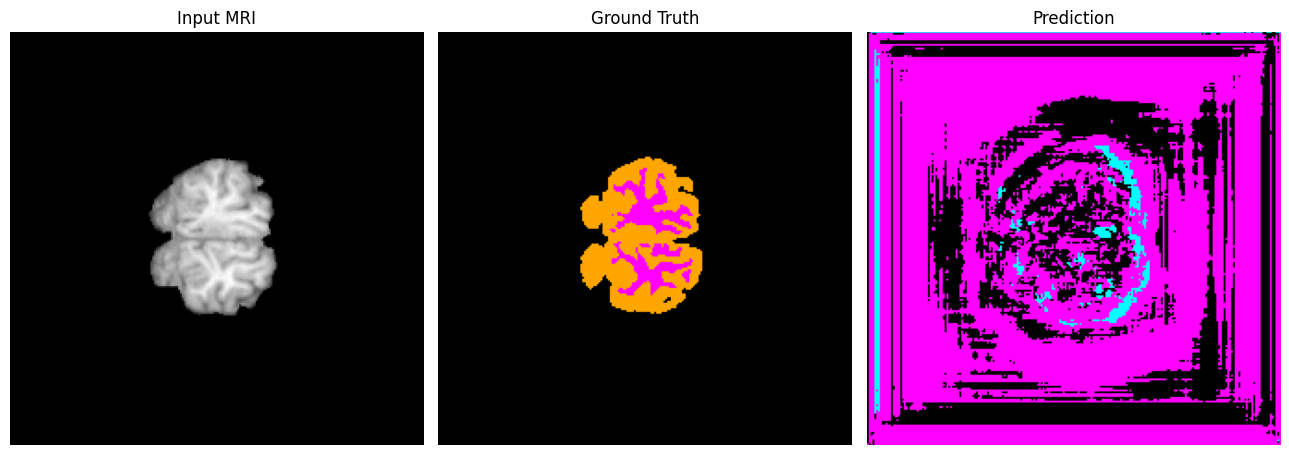

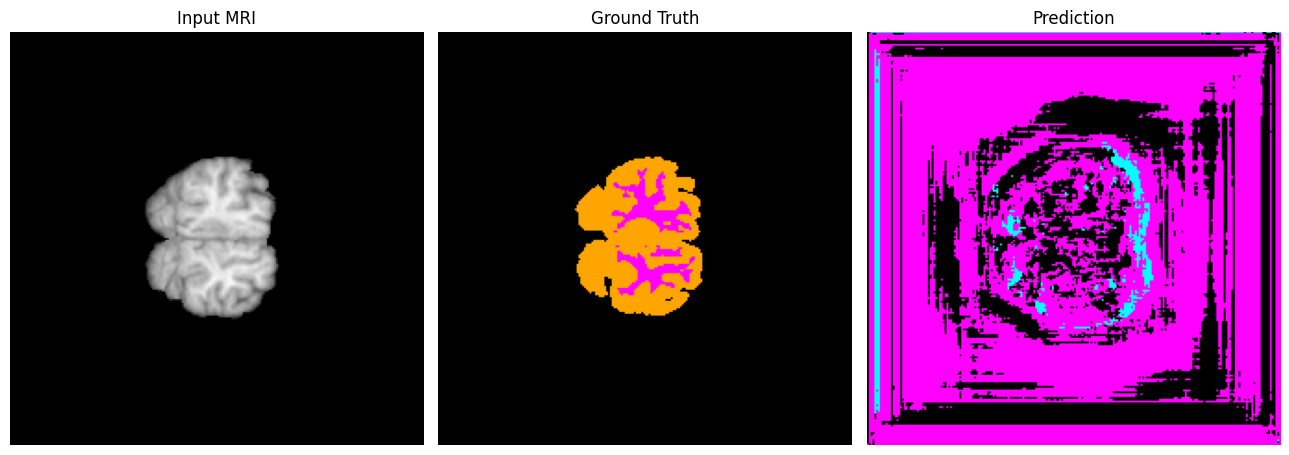

In [56]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)


## 12. Training

Steps per epoch  : 12
Validation steps : 2
Epoch 1/100


2026-06-29 10:10:57.966772: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng2{k2=3,k3=0} for conv %cudnn-conv-bw-input.17 = (f32[16,384,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,224,224]{3,2,1,0} %bitcast.51494, f32[64,384,3,3]{3,2,1,0} %bitcast.44197), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="gradient_tape/VGG19_UNetPP_MultiClass_1/x04_c1_1/convolution/Conv2DBackpropInput" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-06-29 10:10:58.033804: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.067

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - csf_iou: 0.0024 - dice_coefficient_multiclass: 0.2246 - gm_iou: 0.1011 - iou_score_multiclass: 0.1507 - loss: 1.8445 - pixel_accuracy_multiclass: 0.6078 - wm_iou: 0.0589
Epoch 1: val_iou_score_multiclass improved from None to 0.05287, saving model to best_model_vgg19unetpp_multiclass_ibsr.keras

Epoch 1: finished saving model to best_model_vgg19unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - csf_iou: 0.0029 - dice_coefficient_multiclass: 0.2716 - gm_iou: 0.1649 - iou_score_multiclass: 0.1848 - loss: 1.6351 - pixel_accuracy_multiclass: 0.6960 - wm_iou: 0.0866 - val_csf_iou: 3.2218e-04 - val_dice_coefficient_multiclass: 0.0956 - val_gm_iou: 0.0861 - val_iou_score_multiclass: 0.0529 - val_loss: 7.1813 - val_pixel_accuracy_multiclass: 0.0929 - val_wm_iou: 0.1230 - learning_rate: 1.0000e-04
Epoch 2/100
 1/12 ━━━━━━━━━━━━━━━━━━━━ 6:53 38s/step - csf_iou: 9.8924e-06 - dice_coefficient_multiclass: 0.2104 - gm_iou: 0.0989 - iou_sc

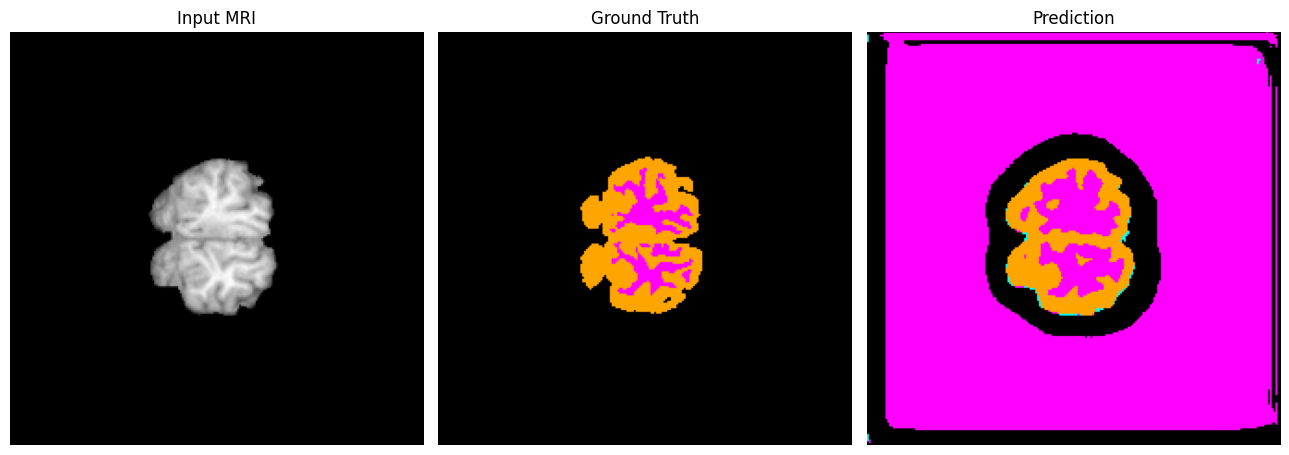

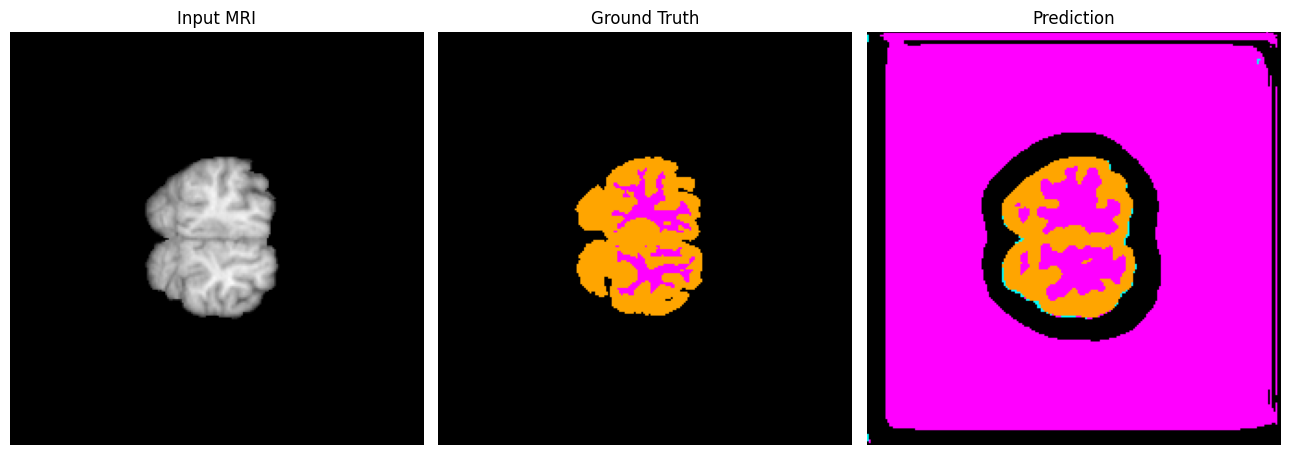

Prediction after epoch 10


Epoch 10: val_iou_score_multiclass improved from 0.14042 to 0.15138, saving model to best_model_vgg19unetpp_multiclass_ibsr.keras

Epoch 10: finished saving model to best_model_vgg19unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 751ms/step - csf_iou: 1.7534e-05 - dice_coefficient_multiclass: 0.2853 - gm_iou: 0.1613 - iou_score_multiclass: 0.2147 - loss: 1.1630 - pixel_accuracy_multiclass: 0.9892 - wm_iou: 0.0342 - val_csf_iou: 0.0021 - val_dice_coefficient_multiclass: 0.2489 - val_gm_iou: 0.2569 - val_iou_score_multiclass: 0.1514 - val_loss: 2.4621 - val_pixel_accuracy_multiclass: 0.3190 - val_wm_iou: 0.1190 - learning_rate: 5.0000e-05
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - csf_iou: 0.0056 - dice_coefficient_multiclass: 0.4977 - gm_iou: 0.5074 - iou_score_multiclass: 0.3952 - loss: 0.7943 - pixel_accuracy_multiclass: 0.9743 - wm_iou: 0.2955
Epoch 11: val_iou_score_multiclass improved from 0.15138 to 0.37704, saving model to best_

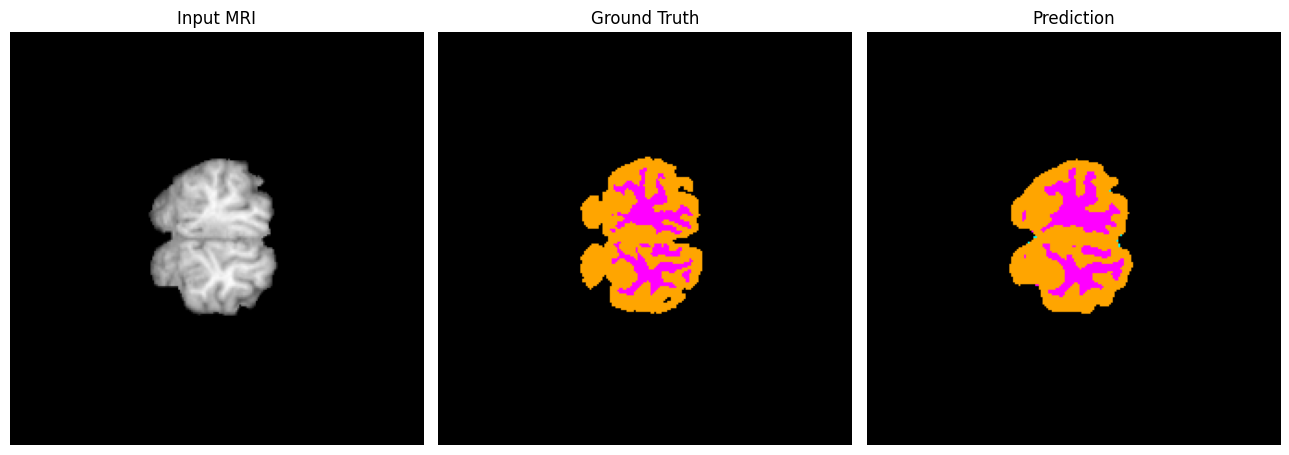

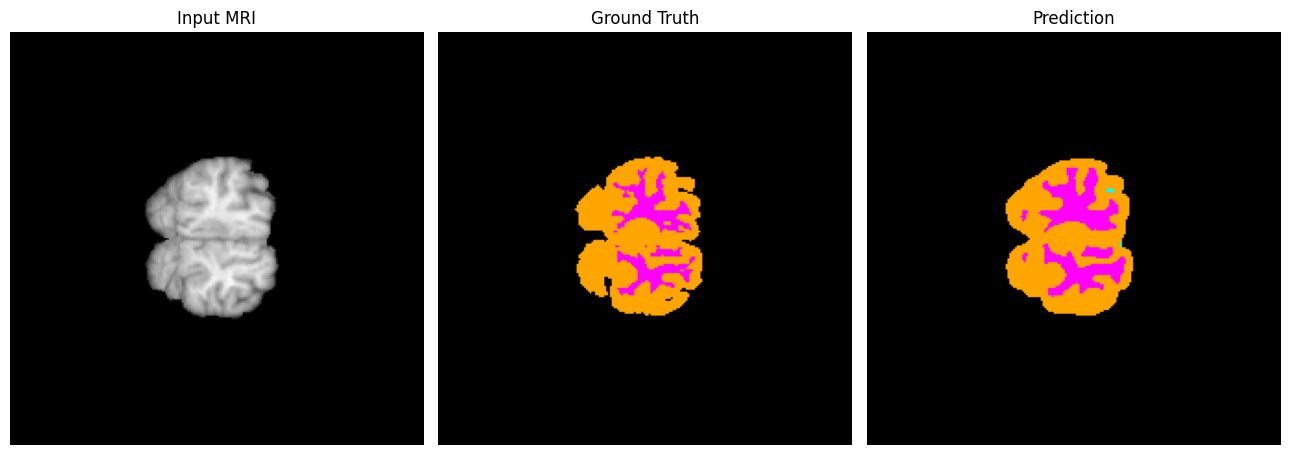

Prediction after epoch 20


Epoch 20: val_iou_score_multiclass did not improve from 0.54386
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 612ms/step - csf_iou: 3.0993e-05 - dice_coefficient_multiclass: 0.3602 - gm_iou: 0.2682 - iou_score_multiclass: 0.2869 - loss: 0.8679 - pixel_accuracy_multiclass: 0.9923 - wm_iou: 0.0633 - val_csf_iou: 0.0192 - val_dice_coefficient_multiclass: 0.6061 - val_gm_iou: 0.7186 - val_iou_score_multiclass: 0.5149 - val_loss: 0.5742 - val_pixel_accuracy_multiclass: 0.9780 - val_wm_iou: 0.4466 - learning_rate: 5.0000e-05
Epoch 21/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - csf_iou: 0.0133 - dice_coefficient_multiclass: 0.5685 - gm_iou: 0.6070 - iou_score_multiclass: 0.4751 - loss: 0.6012 - pixel_accuracy_multiclass: 0.9798 - wm_iou: 0.4072
Epoch 21: val_iou_score_multiclass did not improve from 0.54386
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - csf_iou: 0.0179 - dice_coefficient_multiclass: 0.5742 - gm_iou: 0.5936 - iou_score_multiclass: 0.4788 - loss: 0.5980 - pixel_accurac

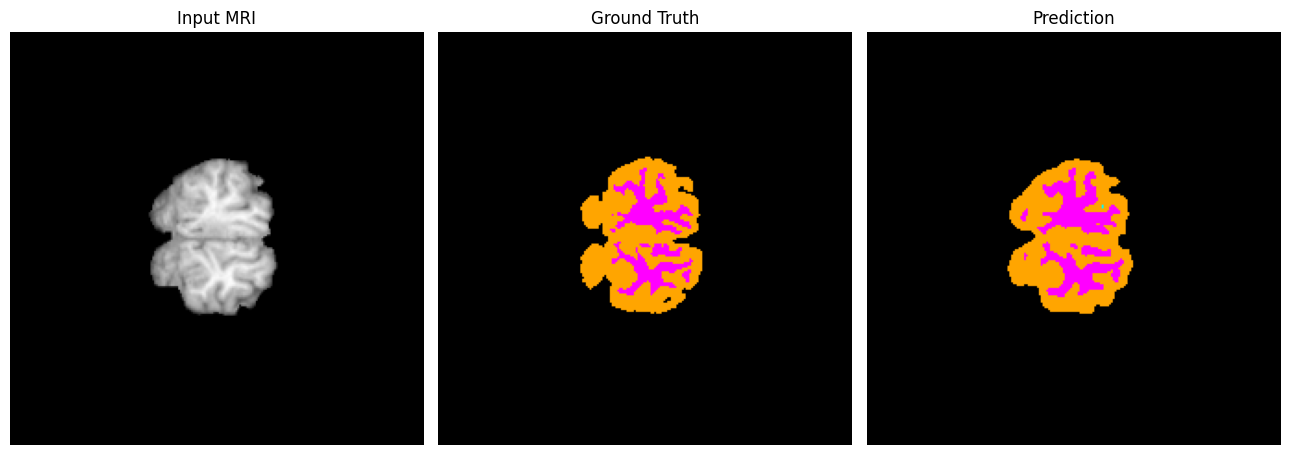

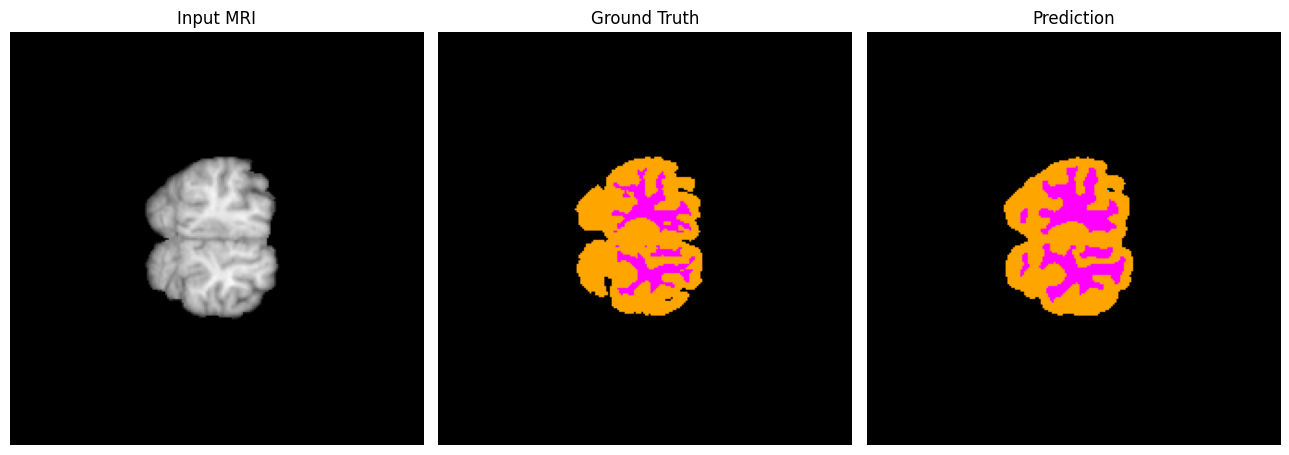

Prediction after epoch 30


Epoch 30: val_iou_score_multiclass did not improve from 0.54386
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 625ms/step - csf_iou: 3.6513e-05 - dice_coefficient_multiclass: 0.3825 - gm_iou: 0.3013 - iou_score_multiclass: 0.3074 - loss: 0.8068 - pixel_accuracy_multiclass: 0.9927 - wm_iou: 0.0809 - val_csf_iou: 0.0265 - val_dice_coefficient_multiclass: 0.6112 - val_gm_iou: 0.6771 - val_iou_score_multiclass: 0.5164 - val_loss: 0.5553 - val_pixel_accuracy_multiclass: 0.9794 - val_wm_iou: 0.4818 - learning_rate: 1.2500e-05
Epoch 31/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - csf_iou: 0.0218 - dice_coefficient_multiclass: 0.5904 - gm_iou: 0.6390 - iou_score_multiclass: 0.4989 - loss: 0.5557 - pixel_accuracy_multiclass: 0.9817 - wm_iou: 0.4435
Epoch 31: val_iou_score_multiclass did not improve from 0.54386
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - csf_iou: 0.0285 - dice_coefficient_multiclass: 0.5956 - gm_iou: 0.6227 - iou_score_multiclass: 0.5017 - loss: 0.5543 - pixel_accurac

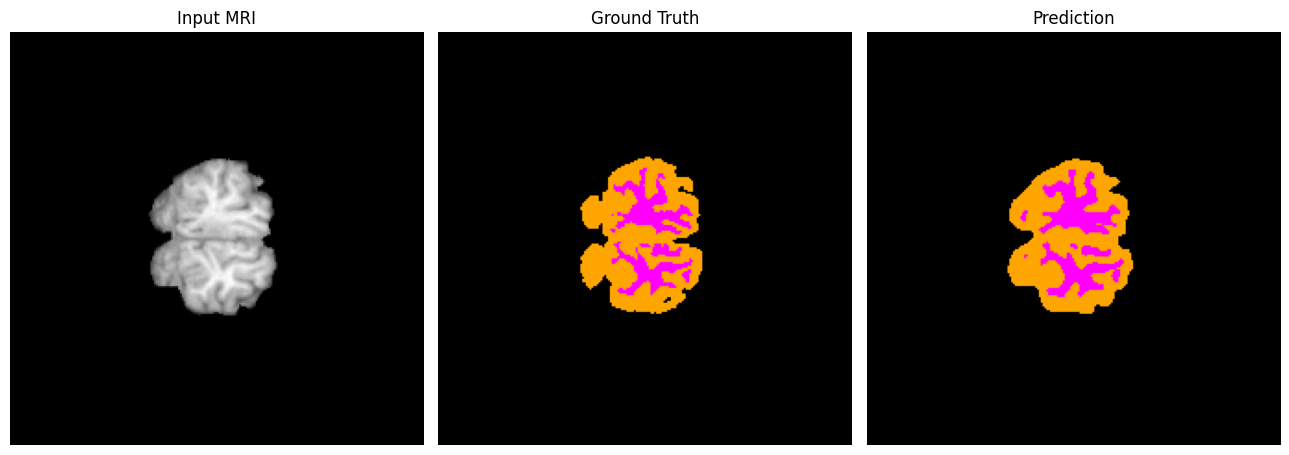

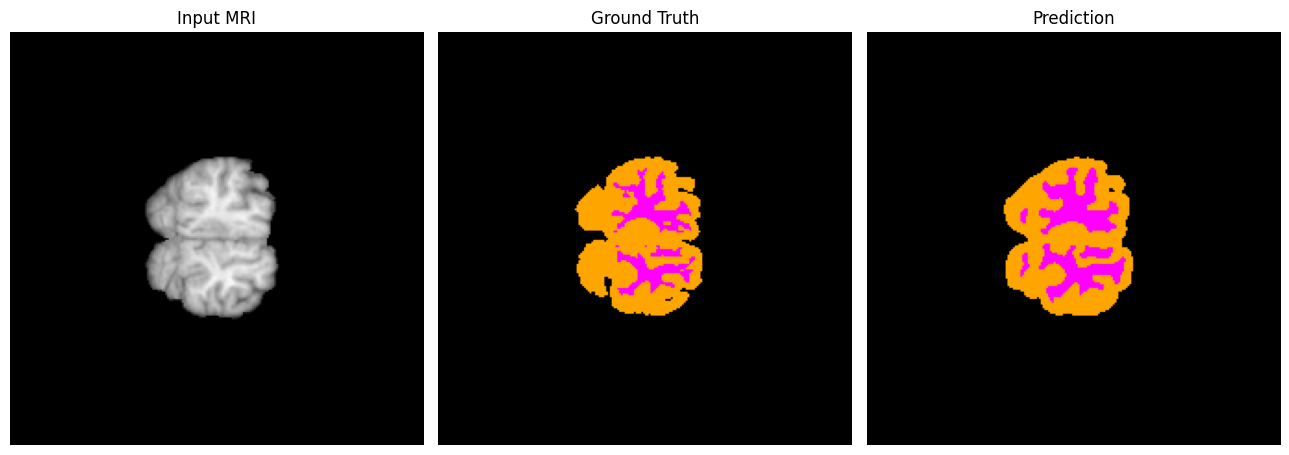

Prediction after epoch 40


Epoch 40: val_iou_score_multiclass improved from 0.54706 to 0.54715, saving model to best_model_vgg19unetpp_multiclass_ibsr.keras

Epoch 40: finished saving model to best_model_vgg19unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 761ms/step - csf_iou: 3.7661e-05 - dice_coefficient_multiclass: 0.3877 - gm_iou: 0.3123 - iou_score_multiclass: 0.3122 - loss: 0.7934 - pixel_accuracy_multiclass: 0.9931 - wm_iou: 0.0834 - val_csf_iou: 0.0335 - val_dice_coefficient_multiclass: 0.6367 - val_gm_iou: 0.7008 - val_iou_score_multiclass: 0.5472 - val_loss: 0.4973 - val_pixel_accuracy_multiclass: 0.9804 - val_wm_iou: 0.5462 - learning_rate: 6.2500e-06
Epoch 41/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - csf_iou: 0.0244 - dice_coefficient_multiclass: 0.5959 - gm_iou: 0.6467 - iou_score_multiclass: 0.5049 - loss: 0.5450 - pixel_accuracy_multiclass: 0.9821 - wm_iou: 0.4530
Epoch 41: val_iou_score_multiclass improved from 0.54715 to 0.54966, saving model to best_

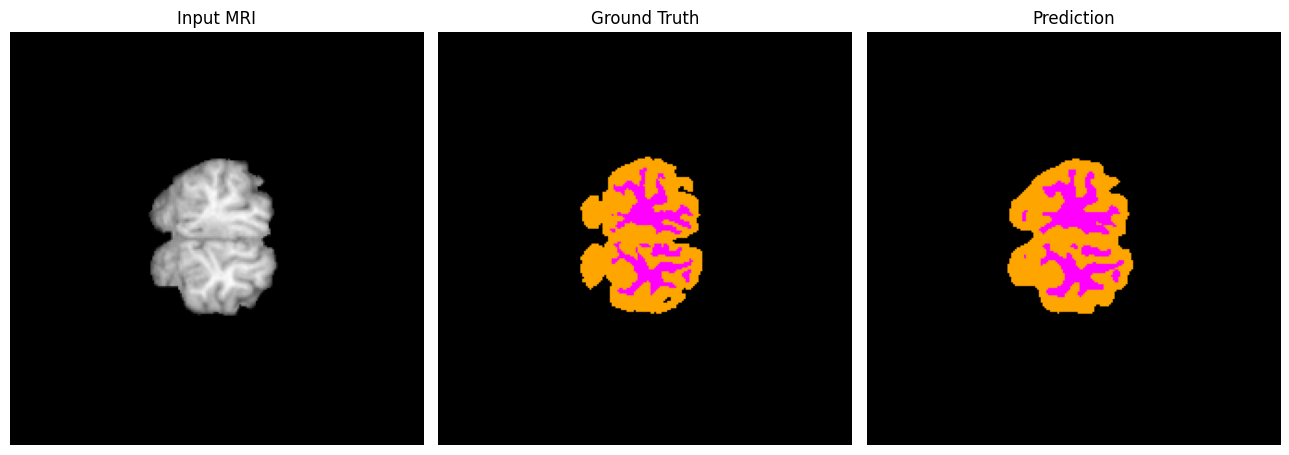

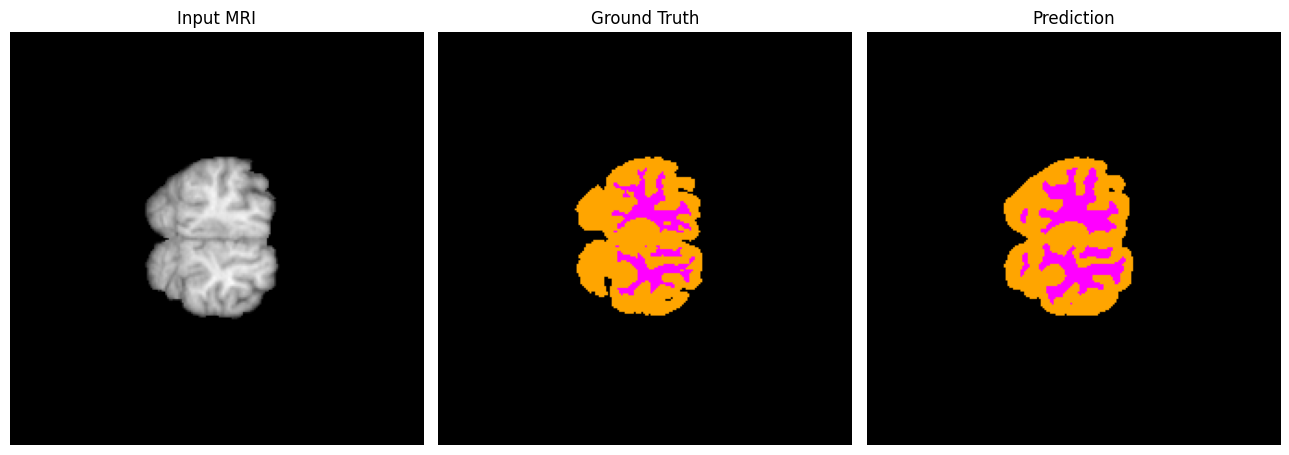

Prediction after epoch 50


Epoch 50: val_iou_score_multiclass improved from 0.55912 to 0.55929, saving model to best_model_vgg19unetpp_multiclass_ibsr.keras

Epoch 50: finished saving model to best_model_vgg19unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 744ms/step - csf_iou: 3.8913e-05 - dice_coefficient_multiclass: 0.3918 - gm_iou: 0.3160 - iou_score_multiclass: 0.3157 - loss: 0.7838 - pixel_accuracy_multiclass: 0.9929 - wm_iou: 0.0889 - val_csf_iou: 0.0387 - val_dice_coefficient_multiclass: 0.6470 - val_gm_iou: 0.7095 - val_iou_score_multiclass: 0.5593 - val_loss: 0.4748 - val_pixel_accuracy_multiclass: 0.9809 - val_wm_iou: 0.5703 - learning_rate: 6.2500e-06
Epoch 51/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - csf_iou: 0.0265 - dice_coefficient_multiclass: 0.6003 - gm_iou: 0.6532 - iou_score_multiclass: 0.5097 - loss: 0.5364 - pixel_accuracy_multiclass: 0.9825 - wm_iou: 0.4602
Epoch 51: val_iou_score_multiclass improved from 0.55929 to 0.56145, saving model to best_

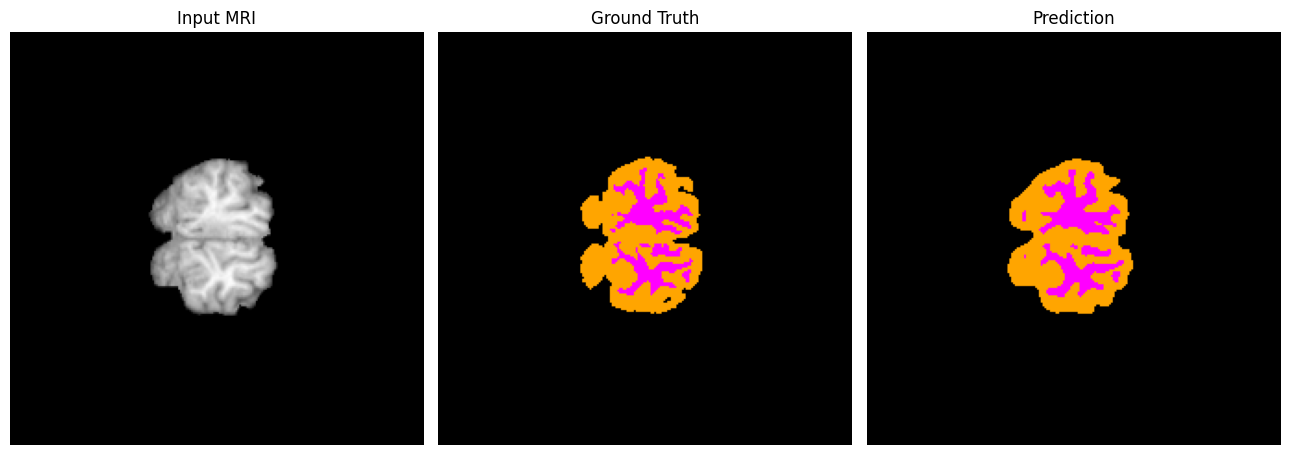

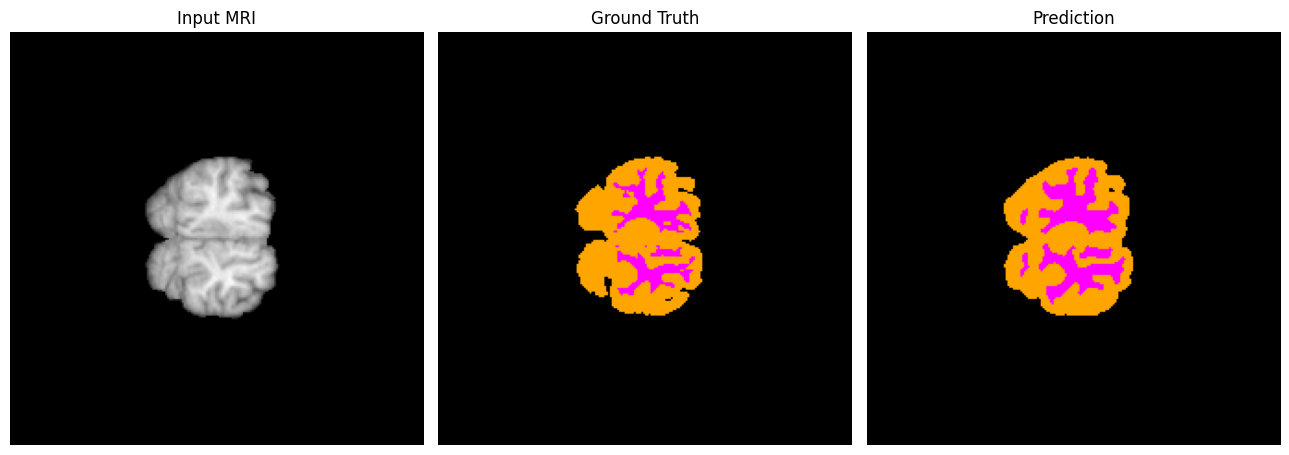

Prediction after epoch 60


Epoch 60: val_iou_score_multiclass improved from 0.56780 to 0.56799, saving model to best_model_vgg19unetpp_multiclass_ibsr.keras

Epoch 60: finished saving model to best_model_vgg19unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 749ms/step - csf_iou: 4.0157e-05 - dice_coefficient_multiclass: 0.3956 - gm_iou: 0.3245 - iou_score_multiclass: 0.3195 - loss: 0.7733 - pixel_accuracy_multiclass: 0.9932 - wm_iou: 0.0906 - val_csf_iou: 0.0433 - val_dice_coefficient_multiclass: 0.6545 - val_gm_iou: 0.7174 - val_iou_score_multiclass: 0.5680 - val_loss: 0.4600 - val_pixel_accuracy_multiclass: 0.9812 - val_wm_iou: 0.5860 - learning_rate: 6.2500e-06
Epoch 61/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - csf_iou: 0.0286 - dice_coefficient_multiclass: 0.6044 - gm_iou: 0.6588 - iou_score_multiclass: 0.5141 - loss: 0.5283 - pixel_accuracy_multiclass: 0.9827 - wm_iou: 0.4674
Epoch 61: val_iou_score_multiclass improved from 0.56799 to 0.57054, saving model to best_

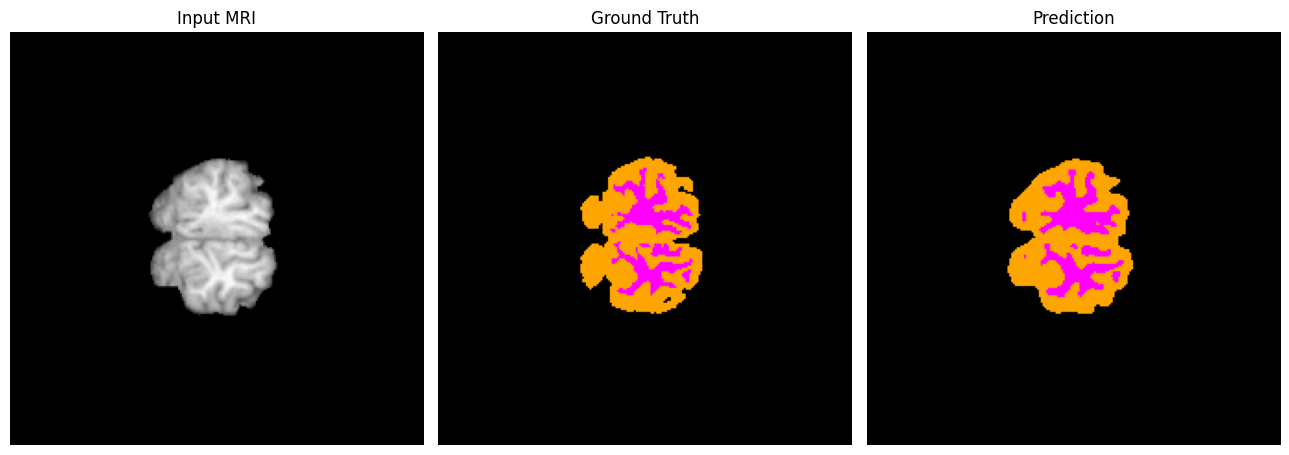

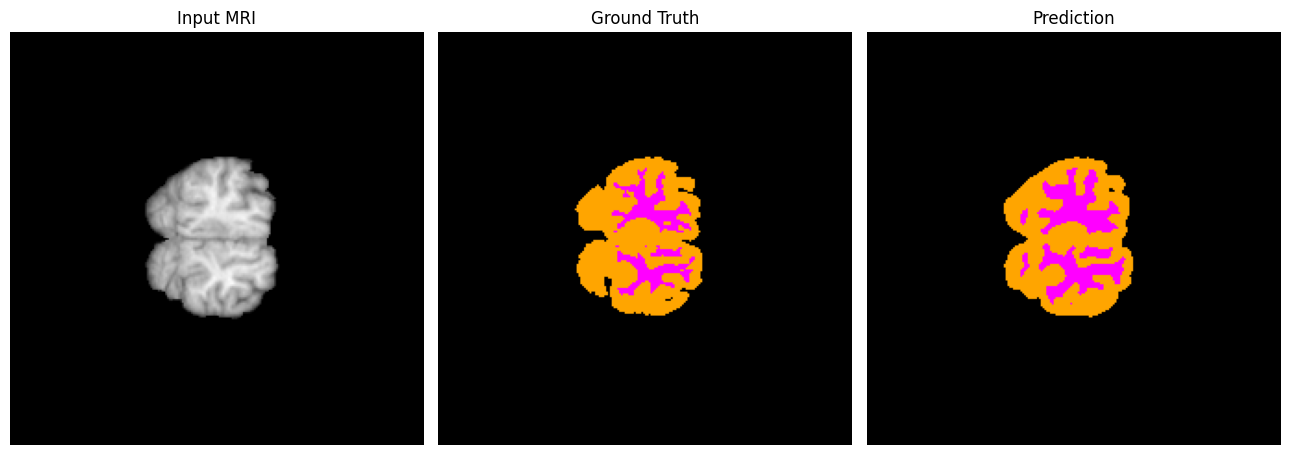

Prediction after epoch 70


Epoch 70: val_iou_score_multiclass did not improve from 0.57366
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 640ms/step - csf_iou: 4.1432e-05 - dice_coefficient_multiclass: 0.3999 - gm_iou: 0.3312 - iou_score_multiclass: 0.3233 - loss: 0.7632 - pixel_accuracy_multiclass: 0.9934 - wm_iou: 0.0948 - val_csf_iou: 0.0470 - val_dice_coefficient_multiclass: 0.6595 - val_gm_iou: 0.7218 - val_iou_score_multiclass: 0.5737 - val_loss: 0.4511 - val_pixel_accuracy_multiclass: 0.9812 - val_wm_iou: 0.5964 - learning_rate: 6.2500e-06
Epoch 71/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - csf_iou: 0.0305 - dice_coefficient_multiclass: 0.6084 - gm_iou: 0.6647 - iou_score_multiclass: 0.5186 - loss: 0.5205 - pixel_accuracy_multiclass: 0.9830 - wm_iou: 0.4743
Epoch 71: val_iou_score_multiclass improved from 0.57366 to 0.57460, saving model to best_model_vgg19unetpp_multiclass_ibsr.keras

Epoch 71: finished saving model to best_model_vgg19unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━

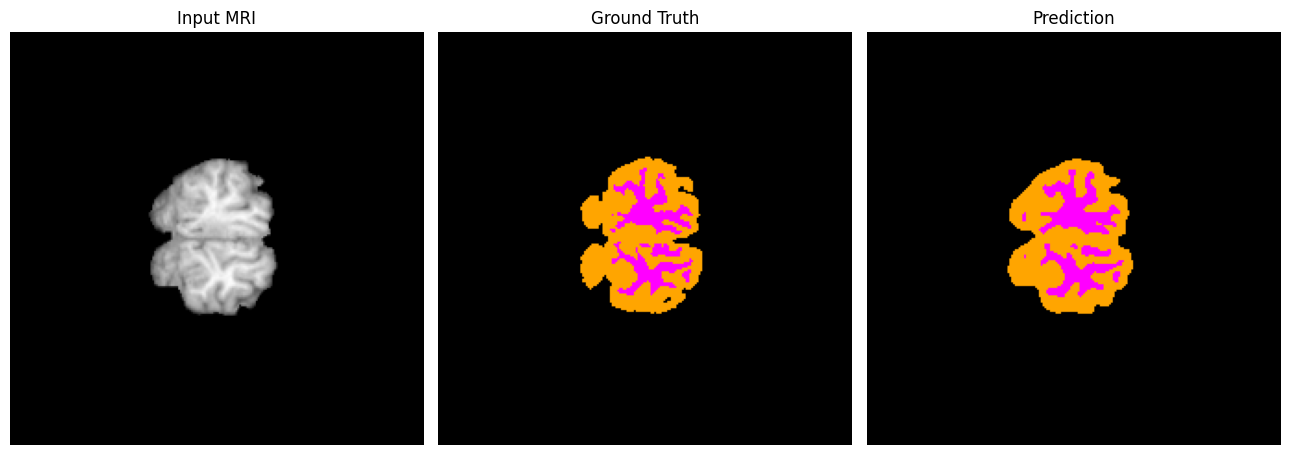

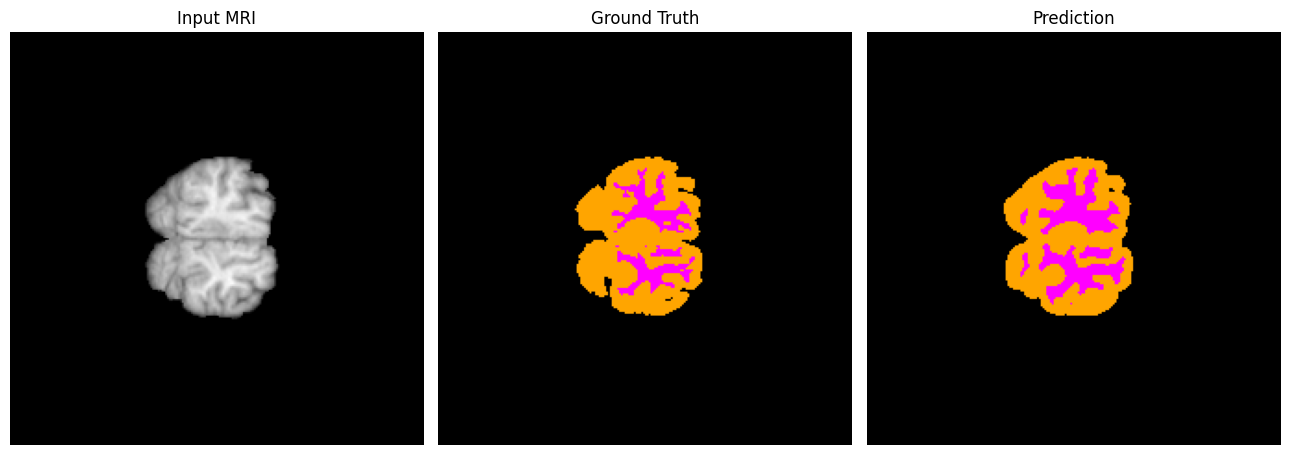

Prediction after epoch 80


Epoch 80: val_iou_score_multiclass did not improve from 0.57874
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 630ms/step - csf_iou: 4.2540e-05 - dice_coefficient_multiclass: 0.4028 - gm_iou: 0.3382 - iou_score_multiclass: 0.3262 - loss: 0.7542 - pixel_accuracy_multiclass: 0.9937 - wm_iou: 0.0959 - val_csf_iou: 0.0500 - val_dice_coefficient_multiclass: 0.6639 - val_gm_iou: 0.7273 - val_iou_score_multiclass: 0.5787 - val_loss: 0.4432 - val_pixel_accuracy_multiclass: 0.9815 - val_wm_iou: 0.6050 - learning_rate: 6.2500e-06
Epoch 81/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - csf_iou: 0.0322 - dice_coefficient_multiclass: 0.6120 - gm_iou: 0.6692 - iou_score_multiclass: 0.5225 - loss: 0.5139 - pixel_accuracy_multiclass: 0.9831 - wm_iou: 0.4810
Epoch 81: val_iou_score_multiclass improved from 0.57874 to 0.57924, saving model to best_model_vgg19unetpp_multiclass_ibsr.keras

Epoch 81: finished saving model to best_model_vgg19unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━

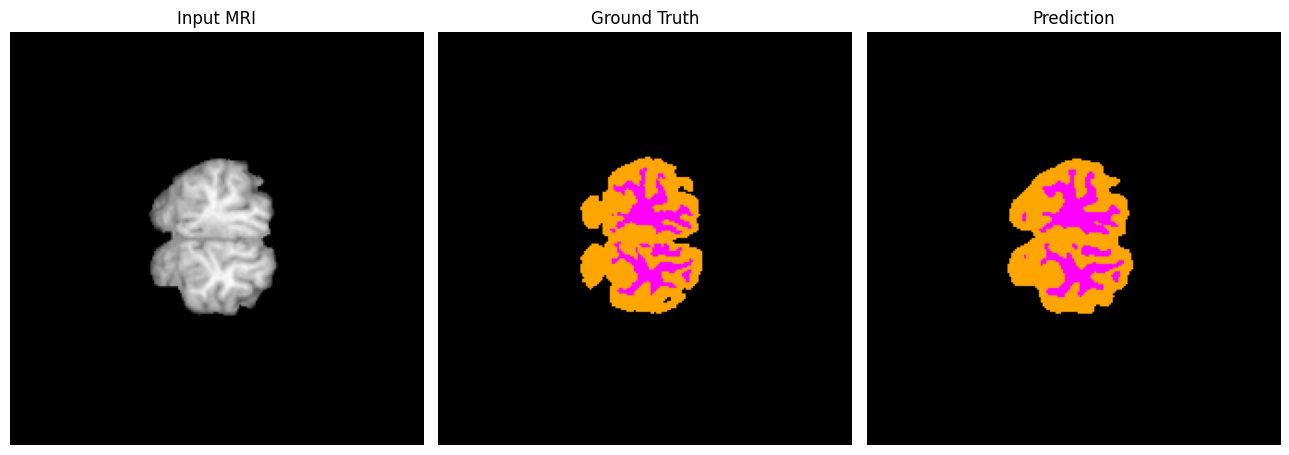

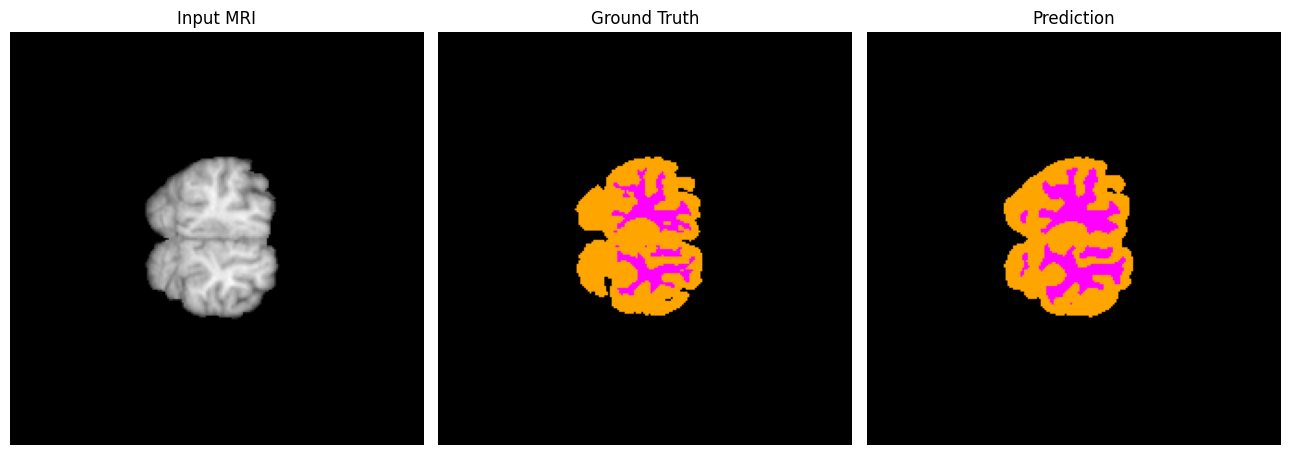

Prediction after epoch 90


Epoch 90: val_iou_score_multiclass did not improve from 0.58298
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 627ms/step - csf_iou: 4.3679e-05 - dice_coefficient_multiclass: 0.4073 - gm_iou: 0.3451 - iou_score_multiclass: 0.3301 - loss: 0.7439 - pixel_accuracy_multiclass: 0.9939 - wm_iou: 0.1008 - val_csf_iou: 0.0523 - val_dice_coefficient_multiclass: 0.6675 - val_gm_iou: 0.7334 - val_iou_score_multiclass: 0.5830 - val_loss: 0.4360 - val_pixel_accuracy_multiclass: 0.9820 - val_wm_iou: 0.6118 - learning_rate: 6.2500e-06
Epoch 91/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - csf_iou: 0.0338 - dice_coefficient_multiclass: 0.6156 - gm_iou: 0.6745 - iou_score_multiclass: 0.5266 - loss: 0.5066 - pixel_accuracy_multiclass: 0.9835 - wm_iou: 0.4878
Epoch 91: val_iou_score_multiclass did not improve from 0.58298
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - csf_iou: 0.0440 - dice_coefficient_multiclass: 0.6220 - gm_iou: 0.6579 - iou_score_multiclass: 0.5302 - loss: 0.5035 - pixel_accurac

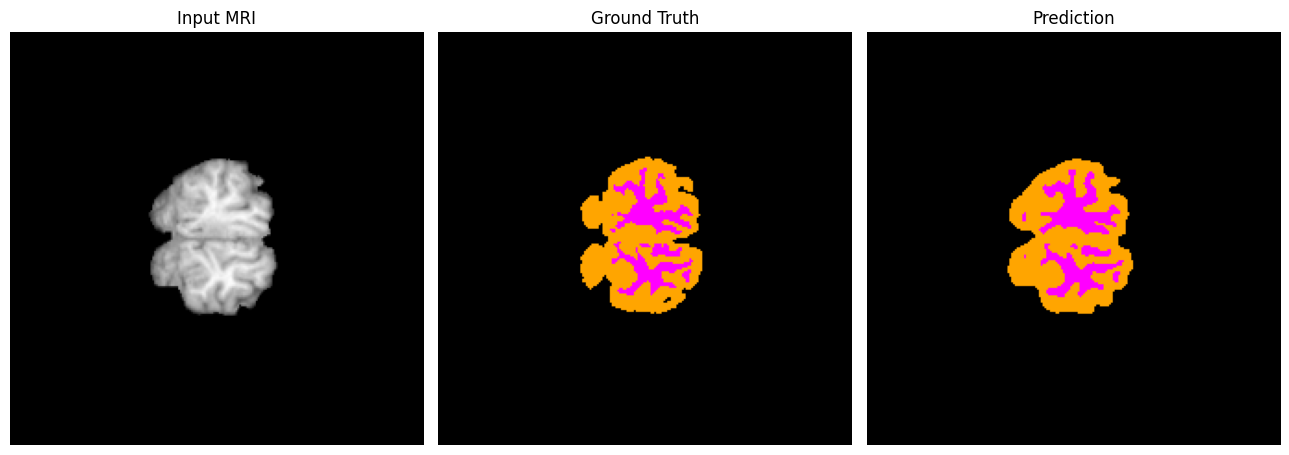

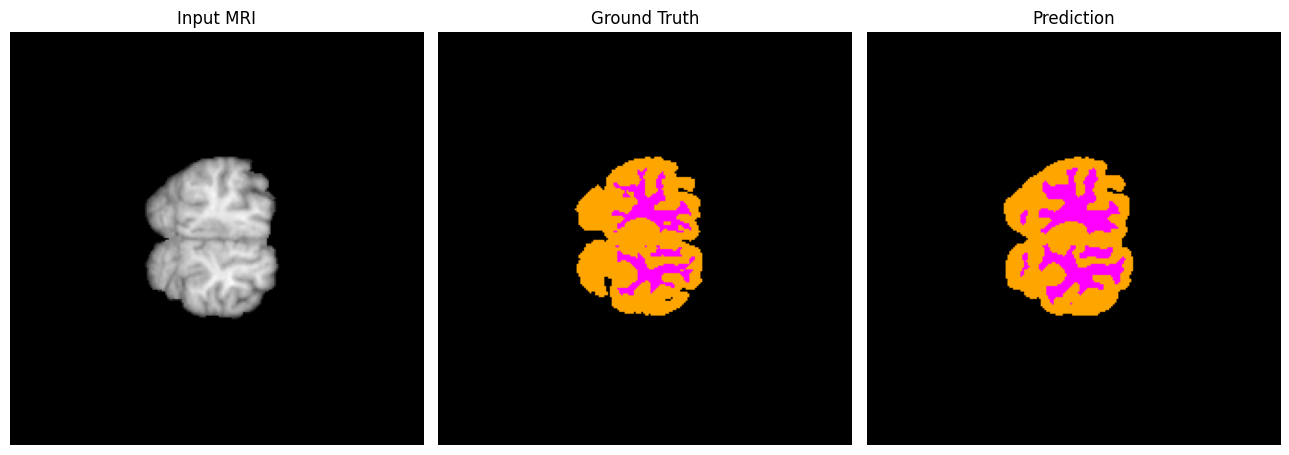

Prediction after epoch 100


Epoch 100: val_iou_score_multiclass did not improve from 0.58614
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 642ms/step - csf_iou: 4.5079e-05 - dice_coefficient_multiclass: 0.4101 - gm_iou: 0.3507 - iou_score_multiclass: 0.3329 - loss: 0.7370 - pixel_accuracy_multiclass: 0.9939 - wm_iou: 0.1026 - val_csf_iou: 0.0545 - val_dice_coefficient_multiclass: 0.6703 - val_gm_iou: 0.7358 - val_iou_score_multiclass: 0.5861 - val_loss: 0.4310 - val_pixel_accuracy_multiclass: 0.9822 - val_wm_iou: 0.6177 - learning_rate: 6.2500e-06

Training time: 21.2 min


In [57]:
steps_per_epoch  = max(1, len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE)
validation_steps = max(1, len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE)
print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()

history = model.fit(
    train_dataset, validation_data=test_dataset, epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch, validation_steps=validation_steps,
    callbacks=callbacks_list
)

elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed/60:.1f} min')


## 13. Training Graphs

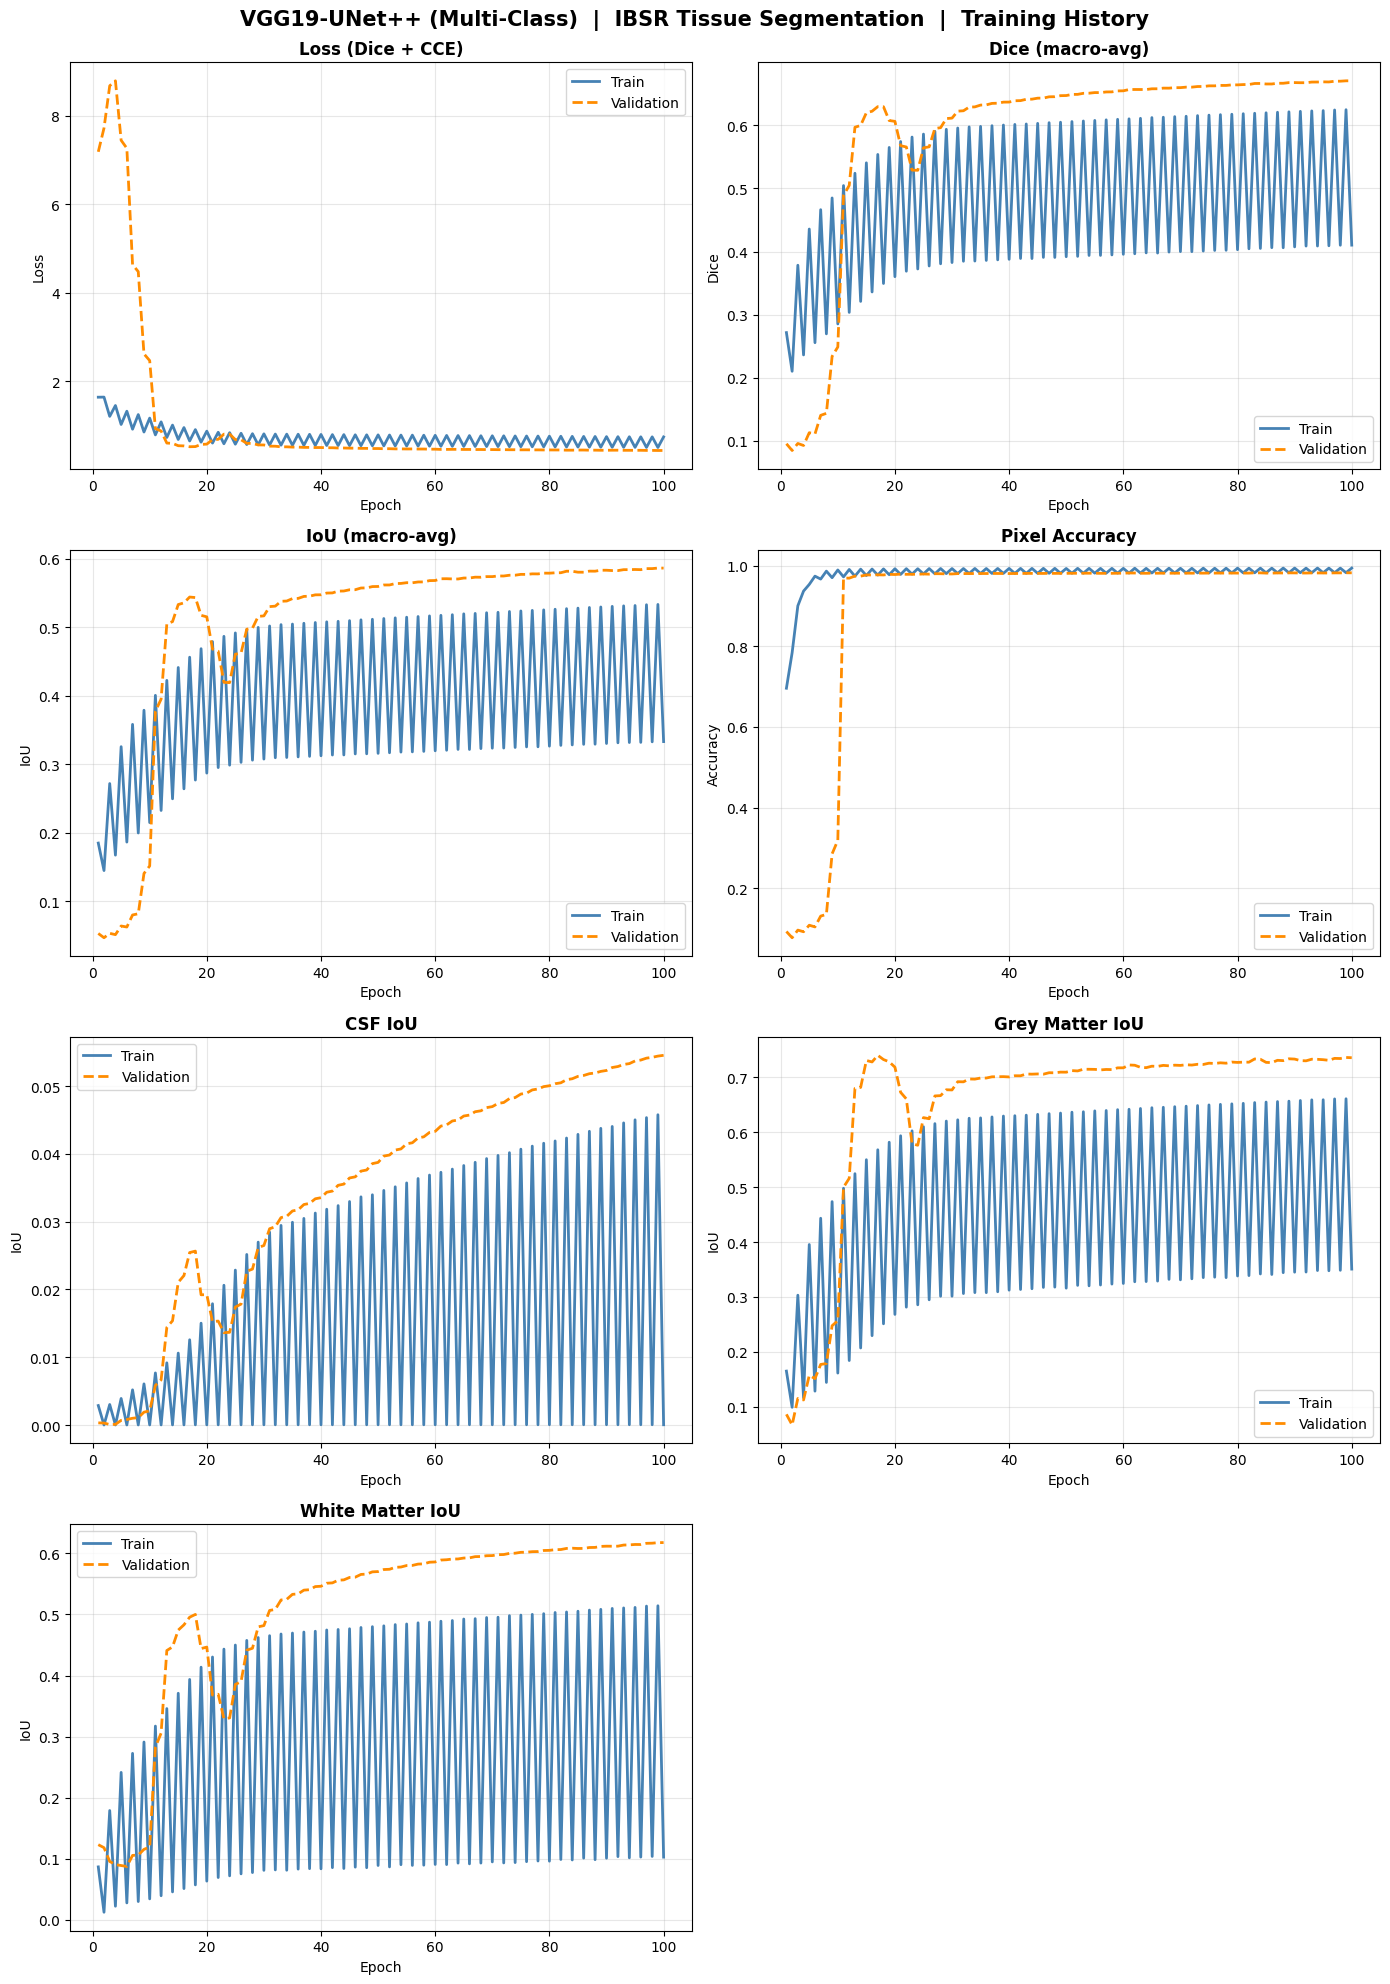

Plot saved ✓


In [58]:
H = history.history

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('VGG19-UNet++ (Multi-Class)  |  IBSR Tissue Segmentation  |  Training History',
             fontsize=15, fontweight='bold', y=0.99)

plot_specs = [
    ('loss', 'val_loss', 'Loss (Dice + CCE)', 'Loss'),
    ('dice_coefficient_multiclass', 'val_dice_coefficient_multiclass', 'Dice (macro-avg)', 'Dice'),
    ('iou_score_multiclass', 'val_iou_score_multiclass', 'IoU (macro-avg)', 'IoU'),
    ('pixel_accuracy_multiclass', 'val_pixel_accuracy_multiclass', 'Pixel Accuracy', 'Accuracy'),
    ('csf_iou', 'val_csf_iou', 'CSF IoU', 'IoU'),
    ('gm_iou', 'val_gm_iou', 'Grey Matter IoU', 'IoU'),
    ('wm_iou', 'val_wm_iou', 'White Matter IoU', 'IoU'),
]

for ax, (train_key, val_key, title, ylabel) in zip(axes.flatten(), plot_specs):
    epochs_range = range(1, len(H[train_key]) + 1)
    ax.plot(epochs_range, H[train_key], label='Train', color='steelblue', linewidth=2)
    ax.plot(epochs_range, H[val_key], label='Validation', color='darkorange', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.savefig('training_history_vgg19unetpp_multiclass_ibsr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')


## 14. Best & Average Metrics Table

In [59]:
metric_spec = [
    ('Loss', 'loss', 'min'),
    ('Dice (macro-avg)', 'dice_coefficient_multiclass', 'max'),
    ('IoU (macro-avg)', 'iou_score_multiclass', 'max'),
    ('Pixel Accuracy', 'pixel_accuracy_multiclass', 'max'),
    ('CSF IoU', 'csf_iou', 'max'),
    ('Grey Matter IoU', 'gm_iou', 'max'),
    ('White Matter IoU', 'wm_iou', 'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key], dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({'Metric': disp, 'Train Best': pick(tr), 'Train Avg': tr.mean(),
                 'Val Best': pick(va), 'Val Avg': va.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)
print('=' * 70)
print('   BEST & AVERAGE METRICS  —  VGG19-UNet++ Multi-Class  |  IBSR')
print('=' * 70)
print(report.to_string())
print('=' * 70)

best_epoch_iou = int(np.argmax(H['val_iou_score_multiclass'])) + 1
print(f'\nBest Val IoU (macro-avg): {max(H["val_iou_score_multiclass"]):.4f}  (epoch {best_epoch_iou})')
print(f'Best Val CSF IoU         : {max(H["val_csf_iou"]):.4f}')
print(f'Best Val Grey Matter IoU : {max(H["val_gm_iou"]):.4f}')
print(f'Best Val White Matter IoU: {max(H["val_wm_iou"]):.4f}')
report


   BEST & AVERAGE METRICS  —  VGG19-UNet++ Multi-Class  |  IBSR
                  Train Best  Train Avg  Val Best  Val Avg
Metric                                                    
Loss                  0.4987     0.7288    0.4307   1.0638
Dice (macro-avg)      0.6246     0.4778    0.6703   0.5880
IoU (macro-avg)       0.5331     0.3929    0.5861   0.5021
Pixel Accuracy        0.9940     0.9797    0.9822   0.8967
CSF IoU               0.0458     0.0152    0.0545   0.0347
Grey Matter IoU       0.6611     0.4484    0.7402   0.6502
White Matter IoU      0.5143     0.2634    0.6177   0.5028

Best Val IoU (macro-avg): 0.5861  (epoch 99)
Best Val CSF IoU         : 0.0545
Best Val Grey Matter IoU : 0.7402
Best Val White Matter IoU: 0.6177


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.4987,0.7288,0.4307,1.0638
Dice (macro-avg),0.6246,0.4778,0.6703,0.5880
IoU (macro-avg),0.5331,0.3929,0.5861,0.5021
Pixel Accuracy,0.9940,0.9797,0.9822,0.8967
CSF IoU,0.0458,0.0152,0.0545,0.0347
Grey Matter IoU,0.6611,0.4484,0.7402,0.6502
White Matter IoU,0.5143,0.2634,0.6177,0.5028


## 15. Load Best Model & Final Evaluation

In [60]:
best_model = tf.keras.models.load_model(
    'best_model_vgg19unetpp_multiclass_ibsr.keras',
    custom_objects={
        'combined_loss_multiclass': combined_loss_multiclass,
        'dice_coefficient_multiclass': dice_coefficient_multiclass,
        'iou_score_multiclass': iou_score_multiclass,
        'pixel_accuracy_multiclass': pixel_accuracy_multiclass,
        'csf_iou': csf_iou, 'gm_iou': gm_iou, 'wm_iou': wm_iou,
    }
)
print('Best model loaded ✓')


Best model loaded ✓


In [61]:
print('Evaluating best model on held-out test set...\n')
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict = dict(zip(best_model.metrics_names, test_results))

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (VGG19-UNet++ Multi-Class | IBSR)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {k:35s}: {v:.4f}')
print('=' * 60)

final_df = pd.DataFrame([{
    'Model': 'VGG19-UNet++ Multi-Class (IBSR)',
    'IoU (macro)': round(test_dict.get('iou_score_multiclass', float('nan')), 4),
    'Dice (macro)': round(test_dict.get('dice_coefficient_multiclass', float('nan')), 4),
    'CSF IoU': round(test_dict.get('csf_iou', float('nan')), 4),
    'GM IoU': round(test_dict.get('gm_iou', float('nan')), 4),
    'WM IoU': round(test_dict.get('wm_iou', float('nan')), 4),
    'Pixel Accuracy': round(test_dict.get('pixel_accuracy_multiclass', float('nan')), 4),
}]).set_index('Model')
final_df


Evaluating best model on held-out test set...

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - csf_iou: 0.0471 - dice_coefficient_multiclass: 0.6694 - gm_iou: 0.7525 - iou_score_multiclass: 0.5881 - loss: 0.4282 - pixel_accuracy_multiclass: 0.9831 - wm_iou: 0.6157

2026-06-29 10:32:01.817964: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 10:32:02.077643: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 10:32:03.140063: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 10:32:03.441966: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - csf_iou: 0.0363 - dice_coefficient_multiclass: 0.6351 - gm_iou: 0.6876 - iou_score_multiclass: 0.5498 - loss: 0.4395 - pixel_accuracy_multiclass: 0.9854 - wm_iou: 0.5369 

  FINAL TEST-SET METRICS  (VGG19-UNet++ Multi-Class | IBSR)
  loss                               : 0.4395
  compile_metrics                    : 0.6351


,IoU (macro),Dice (macro),CSF IoU,GM IoU,WM IoU,Pixel Accuracy
Model,,,,,,
VGG19-UNet++ Multi-Class (IBSR),NaN,NaN,NaN,NaN,NaN,NaN


## 16. Test Predictions Visualization

Test set predictions:


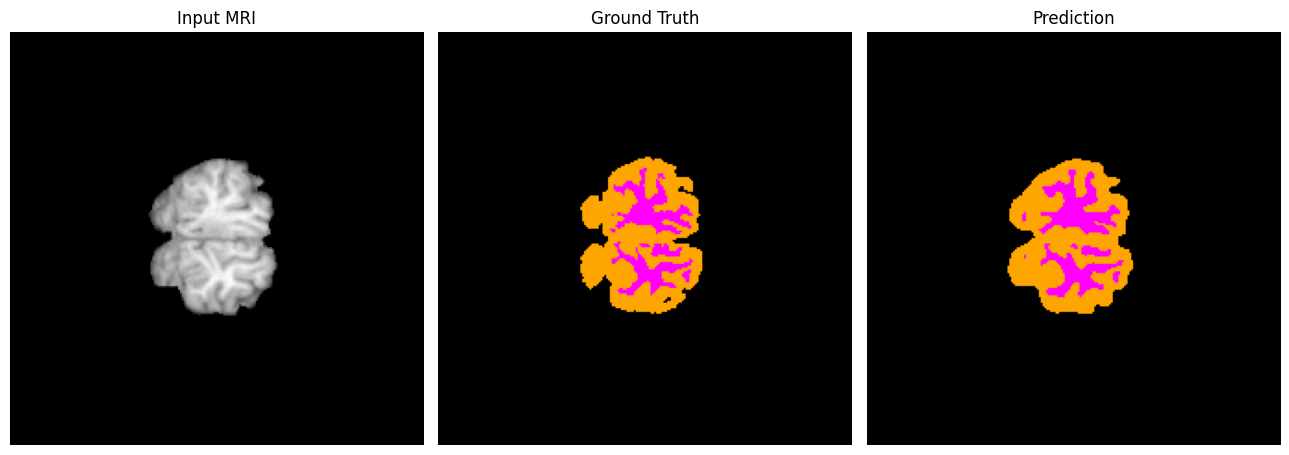

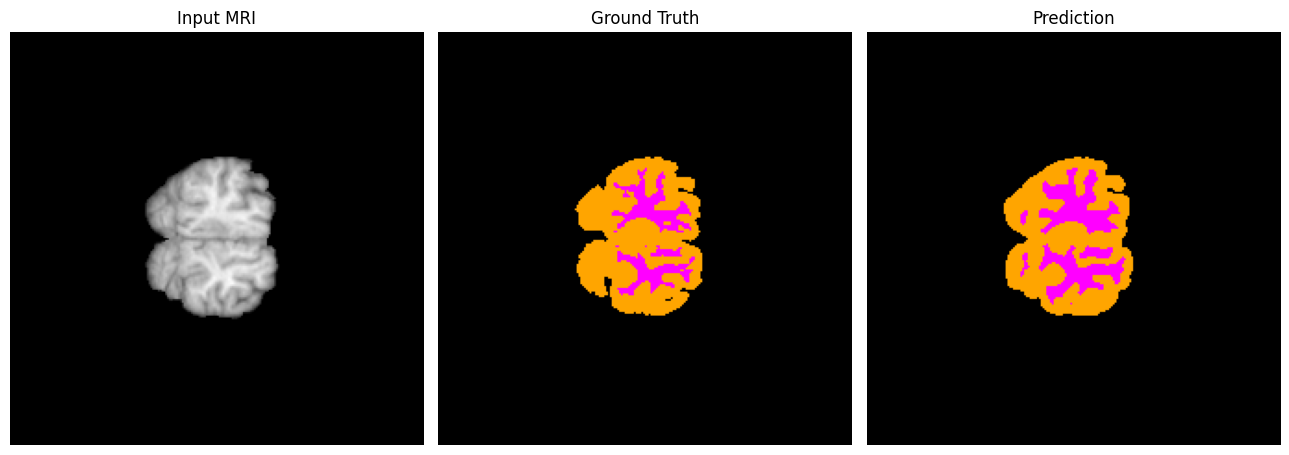

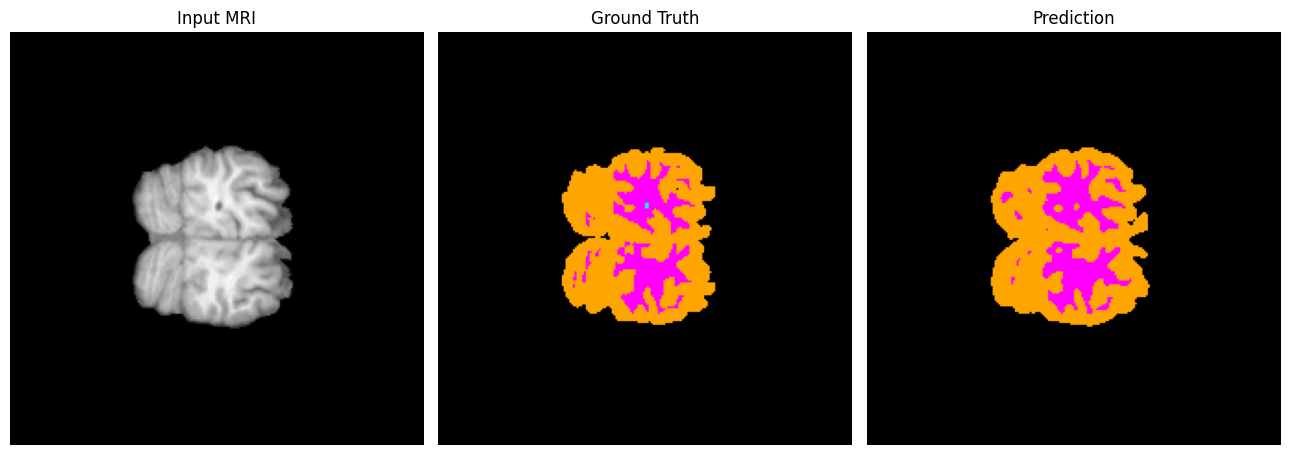

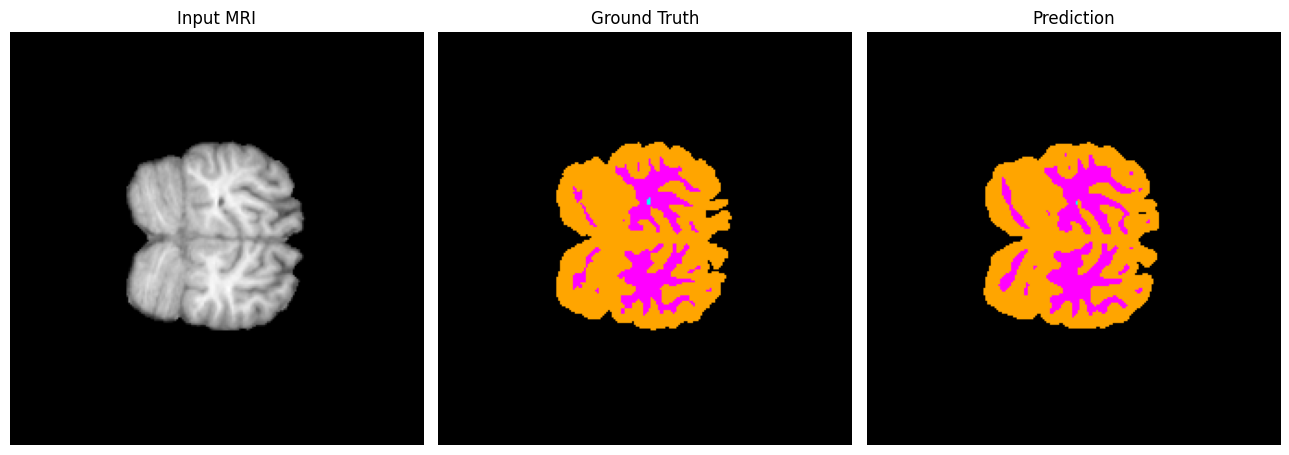

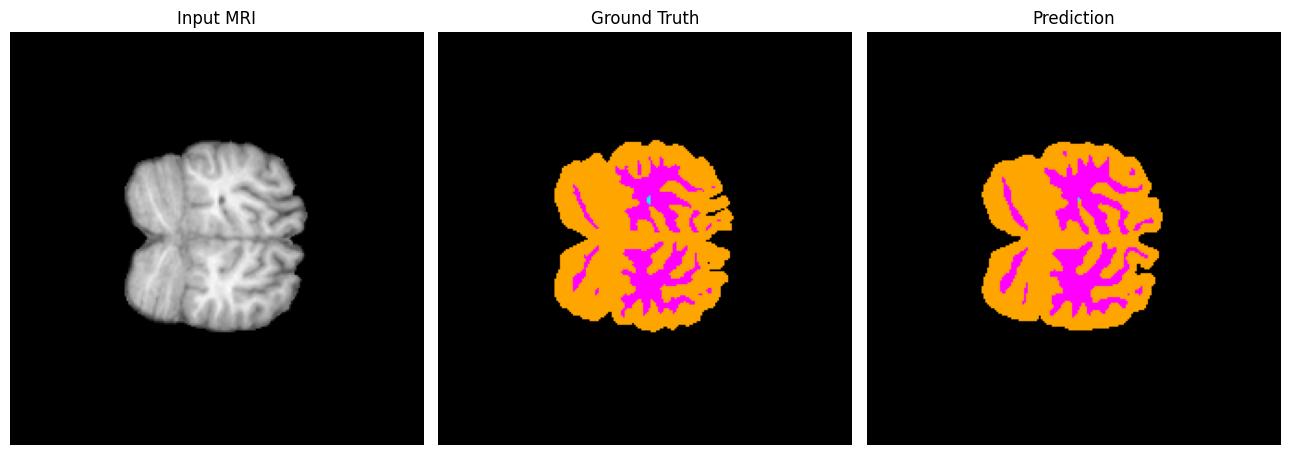

In [62]:
print('Test set predictions:')
show_predictions(test_dataset, num=5, model_to_use=best_model)


## 17. Save Final Model

In [63]:
best_model.save('ibsr_vgg19_unetpp_multiclass_final.keras')
print('Model saved ✓')


Model saved ✓
